# Train model

Este código implementa uma arquitetura LSTM profunda que estuda janelas de 60 dias de preços da Apple.

In [42]:
#importando bibliotecas
import torch
import torch.nn as nn
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [43]:
#importando dados de treino e de teste
data = torch.load('data/curated/training_data.pt')
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

FileNotFoundError: [Errno 2] No such file or directory: 'data/curated/training_data.pt'

### Arquitetura do modelo

Uma **LSTM (Long Short-Term Memory)** é um tipo de Rede Neural Recorrente (RNN) projetada para "lembrar" padrões em sequências de longo prazo. Enquanto redes comuns olham para dados isolados, a LSTM mantém uma "memória interna" (cell state).

*   `input_size=1`: No contexto de séries temporais, isso define a dimensão da entrada em cada passo de tempo. Como estamos alimentando o modelo apenas com o "Preço de Fechamento" de cada dia, a rede recebe um único valor por vez. Se usássemos Preço + Volume, o input_size seria 2.
*   `hidden_size=50`: Representa a capacidade de memória interna de cada camada. São 50 neurônios que funcionam em paralelo para identificar diferentes características (como tendências de alta, volatilidade ou quedas bruscas). Quanto maior esse número, mais padrões complexos o modelo consegue extrair, mas aumenta o risco de "decorar" os dados (overfitting).
*   `num_layers=2`: Define duas camadas de aprendizagem. A primeira camada extrai características iniciais da sequência, enquanto a segunda camada processa essas informações para identificar relações mais abstratas e complexas. Isso melhora o modelo ao aumentar sua capacidade de generalização e permitir que ele aprenda padrões em diferentes níveis de profundidade, algo que uma única camada dificilmente captaria sozinha.
*   `self.fc = nn.Linear(hidden_size, 1)`: A LSTM entrega um vetor abstrato de 50 dimensões (as conclusões dos 50 neurônios). Esta camada aplica pesos matemáticos a cada uma dessas conclusões e as soma para gerar um único número: a previsão do preço para o próximo dia.
*   `out[:, -1, :]`: Esta operação realiza o fatiamento do resultado. Ao processar 60 dias, a LSTM gera uma saída para cada dia. No entanto, como queremos prever apenas o futuro baseado no acúmulo de todo o passado, o índice -1 seleciona apenas a saída do último dia da sequência, que já contém a "memória consolidada" de todos os 59 dias anteriores.

In [ ]:
class AppleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

### Treinamento

O treinamento é um processo iterativo de **"tentativa, erro e ajuste"**. O modelo faz uma previsão, comparamos com o valor real e ajustamos os "pesos" internos para que o erro seja menor na próxima vez.

*   **DataLoader**: Gerencia o fluxo de dados subdividindo o conjunto total em lotes (mini-batches) de 32 amostras. Essa abordagem aumenta a estabilidade computacional e permite que o modelo atualize seus conhecimentos de forma mais frequente, acelerando a convergência.
*   **MSELoss (Mean Squared Error)**: Atua como o critério de avaliação do erro. Ao elevar a diferença entre o valor previsto e o real ao quadrado, esta função penaliza severamente grandes desvios, forçando o modelo a priorizar a correção de erros significativos durante o ajuste dos pesos.
*   **Adam (Otimizador)**: É o algoritmo responsável por gerenciar a atualização dos pesos da rede. Sua principal vantagem é possuir uma taxa de aprendizado adaptativa, o que significa que ele ajusta automaticamente a velocidade com que o modelo aprende, tornando o treinamento mais eficiente e menos propenso a ficar "travado" em erros locais.
*   **O Loop de Retropropagação (Backpropagation)**: Representa o ciclo mecânico de aprendizado, executado em três etapas críticas:
    1.  **`optimizer.zero_grad()`**: Reinicia os gradientes (memória de erro) acumulados na rodada anterior para garantir que o erro de um lote não interfira injustamente no próximo.
    2.  **`loss.backward()`**: Realiza o cálculo matemático que distribui a responsabilidade do erro por todos os neurônios da rede, do final para o início.
    3.  **`optimizer.step()`**: Executa a atualização real dos pesos, movendo os parâmetros do modelo na direção exata que minimiza a função de perda.

In [ ]:
model = AppleLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

#backpropagation
for epoch in range(50):
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

### Avaliação e métricas

A fase de avaliação testa a capacidade de generalização do modelo em dados nunca vistos. Para isso, o ambiente é configurado para garantir que o desempenho medido reflita fielmente o uso real do modelo em produção.

*   **`model.eval()`**: Altera o estado interno do modelo para o modo de avaliação. Isso desativa comportamentos específicos de treinamento (como o *Dropout*), garantindo que as previsões sejam consistentes e determinísticas durante os testes.
*   **`torch.no_grad()`**: Desativa o motor de cálculo de gradientes do PyTorch. Como não haverá atualização de pesos nesta etapa, essa operação reduz drasticamente o consumo de memória RAM e acelera o processamento das previsões.
*   **MAE (Mean Absolute Error)**: Calcula a média aritmética da magnitude dos erros. É uma métrica linear que indica, em média, o quão distante a previsão está do valor real, mantendo a mesma unidade de medida dos dados.
*   **RMSE (Root Mean Square Error)**: Mede a raiz quadrática da média dos erros elevados ao quadrado. Por sua natureza matemática, esta métrica penaliza de forma mais severa os erros de grande magnitude, sendo ideal para identificar se o modelo está cometendo falhas críticas pontuais (outliers).
*   **MAPE (Mean Absolute Percentage Error)**: Representa o erro médio em termos percentuais. No contexto financeiro, é a métrica mais intuitiva para tomada de decisão, pois permite quantificar a precisão do modelo em relação ao valor da ação (ex: "o modelo apresenta um erro médio de 1,60% sobre o preço real").

In [ ]:
#avaliação
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy().flatten()
    y_true = y_test.numpy().flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'Metrics (Normalized Data):')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.2f}%')

Metrics (Normalized Data):
MAE: 0.0181
RMSE: 0.0246
MAPE: 2.53%


### Visualização

Em séries temporais, o olho humano é o melhor validador. Precisamos ver se a curva prevista (laranja) segue a tendência e a volatilidade da curva real (azul).

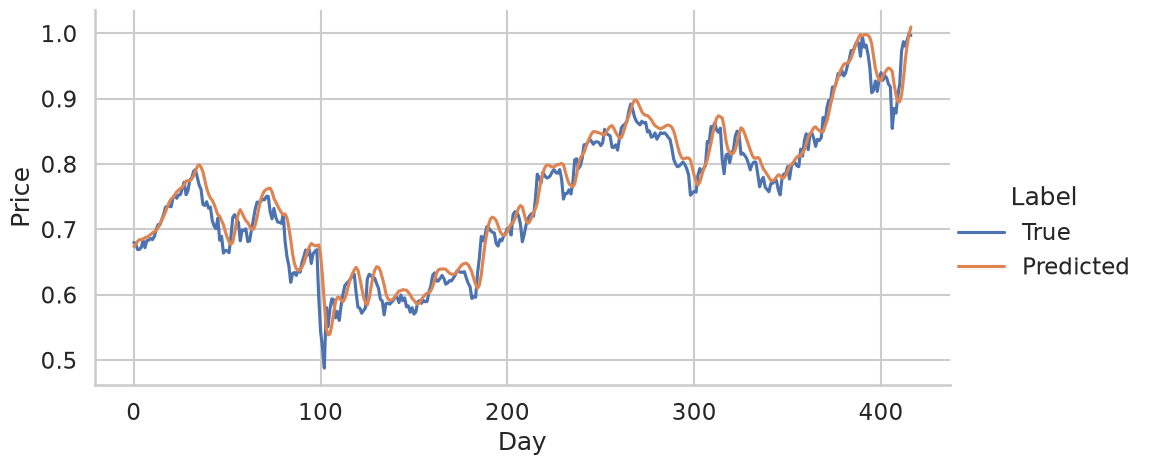

In [50]:
df = pd.DataFrame({
    'Day': list(range(len(y_true))) * 2,
    'Price': list(y_true) + list(y_pred),
    'Label': ['True'] * len(y_true) + ['Predicted'] * len(y_pred)
})

fig = sns.relplot(
    data=df, 
    x='Day', 
    y='Price', 
    hue='Label', 
    kind='line', 
    aspect=2
)

In [ ]:
#salvando o modelo
torch.save(model.state_dict(), 'models/model.pth')

### Exemplo de uso

In [ ]:
model = AppleLSTM() #necessário carregar a classe para o PyTorch carregar os pesos
model.load_state_dict(torch.load('models/model.pth'))
model.eval() #definindo modo de previsão

#carregando o scaler para desnormalizar os dados
scaler = joblib.load('models/scaler.pkl')

#preparando os dados dos últimos 60 dias
df = pd.read_pickle('data/raw/raw_data.pkl')

data = df['Close'].tail(60).values.reshape(-1, 1)

#normalizando e transformando para tensores
data_scaled = scaler.transform(data)
X_input = torch.FloatTensor(data_scaled).view(1, 60, 1)

#realizando predições
with torch.no_grad():
    y_pred_norm = model(X_input)

#convertendo para valores monetários
price = scaler.inverse_transform(y_pred_norm.numpy())

print(f'Previsão para o próximo dia útil: ${price[0][0]:.2f}')

Previsão para o próximo dia útil: $320.55
